# Credit Card Fraud Detection
**Author:** Ramya Sri Immadi  
**Date:** August 2026  

Detecting fraudulent credit card transactions using Machine Learning. The dataset contains 284,807 transactions with only 492 (0.17%) being fraud — a highly imbalanced classification problem. We use SMOTE for oversampling and compare Logistic Regression vs XGBoost.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

## 2. Load Dataset
The dataset is from Kaggle's Credit Card Fraud Detection dataset. It contains transactions made by European cardholders over two days in September 2013.

In [2]:
data = pd.read_csv("creditcard.csv")

## 3. Exploratory Data Analysis
- **284,807 transactions**, 31 columns
- **V1-V28**: PCA-transformed features (anonymized for privacy)
- **Time**: Seconds elapsed from the first transaction
- **Amount**: Transaction amount (not scaled)
- **Class**: Target variable (0 = Legit, 1 = Fraud)

In [3]:
data.head()
data.describe()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 3.1 Check for Missing Values

In [4]:
print(data.isnull().sum())
print("\nTotal missing values:", data.isnull().sum().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


In [5]:
data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### 3.2 Class Distribution
Only **492 out of 284,807** transactions are fraud — that's just **0.17%**. This extreme imbalance means accuracy alone is a misleading metric. A model predicting everything as "legit" would be 99.83% accurate but completely useless.

In [6]:
Fraud_percentage = (492 / 284807) * 100
Fraud_percentage

0.1727485630620034

## 4. Visualize Class Imbalance

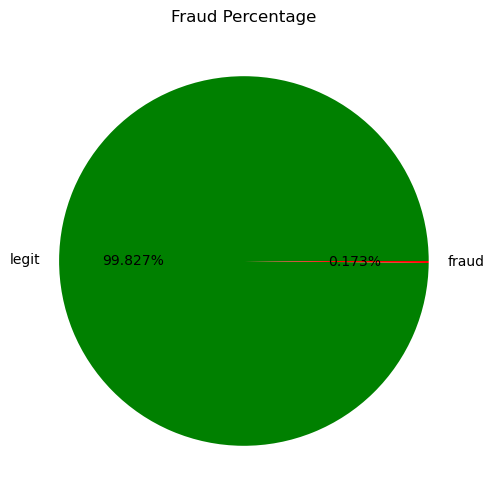

In [7]:
plt.figure(figsize=(6,6))
plt.title("Fraud Percentage")
plt.pie(data['Class'].value_counts(),
        labels=['legit','fraud'],
        autopct="%1.3f%%",
        colors=['green','red']
       )
plt.show()

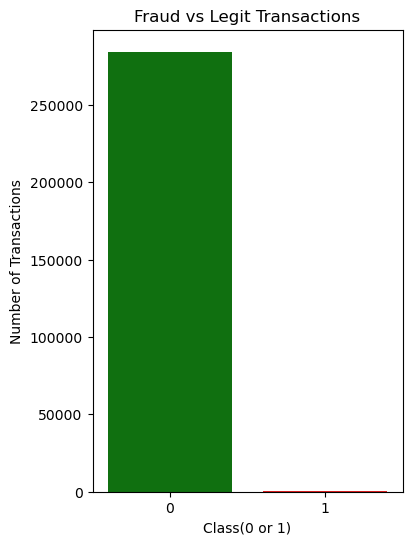

In [8]:
plt.figure(figsize=(4,6))
plt.title("Fraud vs Legit Transactions")
sns.countplot(x='Class',
              data=data,
              hue='Class',
              palette=['green','red'],
              legend=False
            )
plt.xlabel('Class(0 or 1)')
plt.ylabel('Number of Transactions')
plt.show()

## 5. Amount & Time Distribution

**Key Observations:**
- **Amount**: Most fraud transactions are small (under $500). Fraudsters keep amounts low to avoid triggering bank alerts.
- **Time**: Legit transactions follow a clear day-night cycle (two peaks = two days). Fraud is more uniformly distributed — fraudsters operate even during off-peak hours.

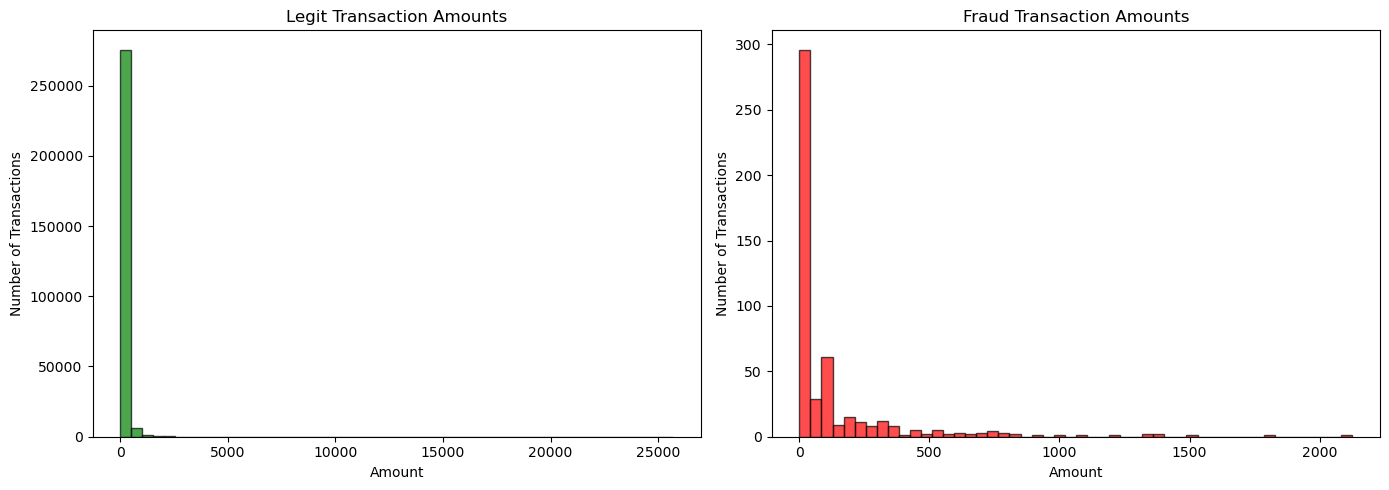

In [9]:
legit_amounts = data[data['Class'] == 0]['Amount']
fraud_amounts = data[data['Class'] == 1]['Amount']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(legit_amounts, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Legit Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Number of Transactions')

plt.subplot(1, 2, 2)
plt.hist(fraud_amounts, bins=50, color='red', edgecolor='black', alpha=0.7)
plt.title('Fraud Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Number of Transactions')

plt.tight_layout() 
plt.show()

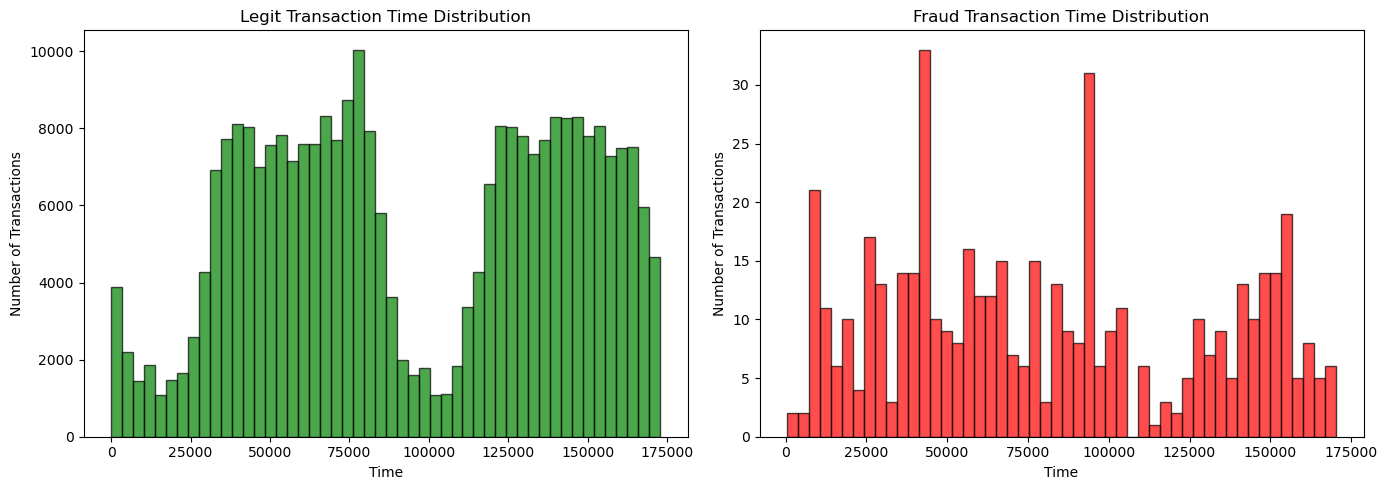

In [10]:
legit_time = data[data['Class'] == 0]['Time']
fraud_time = data[data['Class'] == 1]['Time']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(legit_time, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title("Legit Transaction Time Distribution")
plt.xlabel('Time')
plt.ylabel('Number of Transactions')

plt.subplot(1, 2, 2)
plt.hist(fraud_time, bins=50, color='red', edgecolor='black', alpha=0.7)
plt.title("Fraud Transaction Time Distribution")
plt.xlabel('Time')
plt.ylabel('Number of Transactions')

plt.tight_layout() 
plt.show()

## 6. Feature Scaling
V1-V28 are already PCA-scaled, but **Amount** (0 to 25,000) and **Time** are on completely different scales. We apply StandardScaler to bring them to the same range. Unscaled features can bias distance-based and gradient-based models.

In [11]:
X = data.drop(columns=['Amount', 'Time','Class'])
y = data.iloc[: , -1]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[['Amount', 'Time']])
X[['Amount_Scaled', 'Time_Scaled']] = scaled_features

X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_Scaled,Time_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,-1.996541


## 7. Train/Test Split
- **80% train, 20% test**
- **stratify=y** ensures the 0.17% fraud ratio is preserved in both splits. Without this, the test set might randomly have very few or zero fraud samples.

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size = 0.2,
                                                 random_state = 42,
                                                 stratify= y
                                                )

## 8. Handle Class Imbalance with SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) creates **synthetic fraud samples** by interpolating between existing fraud data points. This balances the training set without simply duplicating rows.

⚠️ **SMOTE is applied ONLY on the training set** — never on test data. If synthetic samples leak into the test set, evaluation metrics become unreliable.

In [13]:
print(y_train.value_counts())
smote = SMOTE()
X_train,y_train = smote.fit_resample(X_train,y_train)
y_train.value_counts()


Class
0    227451
1       394
Name: count, dtype: int64


NameError: name 'SMOTE' is not defined

## 9. Model 1: Logistic Regression (Baseline)
A simple linear model to establish a performance baseline before trying more complex models.

In [ ]:
logistic_model = LogisticRegression(random_state = 42)
logistic_model.fit(X_train,y_train)
y_pred = logistic_model.predict(X_test)
print(classification_report(y_test,y_pred))
cm_logistic = confusion_matrix(y_test,y_pred)
print("Confusion_Matrix")
print(cm_logistic)
y_proba_logistic = logistic_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score")
print(roc_auc_score(y_test,y_proba))

## 10. Model 2: XGBoost
Gradient-boosted decision tree model. Expected to outperform Logistic Regression on this non-linear, imbalanced dataset.

In [ ]:
XGB_model = XGBClassifier(random_state = 42)
XGB_model.fit(X_train,y_train)
y_pred = XGB_model.predict(X_test)
print(classification_report(y_test,y_pred))
print("Confusion_Matrix")
cm_XGB = confusion_matrix(y_test,y_pred)
print(cm_XGB)
y_proba_XGB = XGB_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score")
print(roc_auc_score(y_test,y_proba))

## 11. Results Visualization
### Confusion Matrix Comparison

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm_XGB, 
    annot=True,
    fmt='d',               
    cmap='Blues',
    xticklabels=['Legit', 'Fraud'], 
    yticklabels=['Legit', 'Fraud']
)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(
    cm_logistic, 
    annot=True,
    fmt='d',               
    cmap='Blues',
    xticklabels=['Legit', 'Fraud'], 
    yticklabels=['Legit', 'Fraud']
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### ROC Curve Comparison
The ROC curve plots True Positive Rate vs False Positive Rate at all classification thresholds. A perfect model hugs the top-left corner (AUC = 1.0). The diagonal line represents a random model (AUC = 0.5).

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_test, y_proba_logistic)
auc_score = roc_auc_score(y_test, y_proba_logistic)
plt.plot(fpr, tpr, color='royalblue', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba_XGB)
auc_score = roc_auc_score(y_test, y_proba_XGB)
plt.plot(fpr, tpr, color='royalblue', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost - ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

## 12. Conclusion

| Metric | Logistic Regression | XGBoost |
|--------|-------------------|---------|
| Precision (Fraud) | 0.06 | **0.71** |
| Recall (Fraud) | **0.92** | 0.88 |
| F1 Score (Fraud) | 0.11 | **0.79** |
| ROC-AUC | 0.97 | **0.98** |
| False Positives | 1,458 | **35** |

**XGBoost is the clear winner.** It reduces false positives by 97.6% (1,458 → 35) while maintaining strong fraud detection (88% recall). In a production banking system, this means far fewer legitimate customers getting wrongly blocked.